In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format


In [2]:
NG_data = pd.read_csv('NorthGrid_regressionData.csv')
display(NG_data)


,date,revenue,production,coolDD,heatDD,type
0,2015-01-01,11650909,393487,47,455,dt4training
1,2015-02-01,18574693,721907,22,609,dt4training
2,2015-03-01,17476678,597236,61,203,dt4training
3,2015-04-01,14339607,521235,36,93,dt4training
4,2015-05-01,8105319,268930,178,33,dt4training
5,2015-06-01,12826066,268916,451,9,dt4training
6,2015-07-01,11362440,213107,493,35,dt4training
7,2015-08-01,20059530,673720,314,13,dt4training
8,2015-09-01,16190319,522635,180,30,dt4training
9,2015-10-01,15897373,583601,46,97,dt4training


In [3]:
# Make sure dates are recognized as dates
NG_data['date'] = pd.to_datetime(NG_data['date'])
display(NG_data)


,date,revenue,production,coolDD,heatDD,type
0,2015-01-01,11650909,393487,47,455,dt4training
1,2015-02-01,18574693,721907,22,609,dt4training
2,2015-03-01,17476678,597236,61,203,dt4training
3,2015-04-01,14339607,521235,36,93,dt4training
4,2015-05-01,8105319,268930,178,33,dt4training
5,2015-06-01,12826066,268916,451,9,dt4training
6,2015-07-01,11362440,213107,493,35,dt4training
7,2015-08-01,20059530,673720,314,13,dt4training
8,2015-09-01,16190319,522635,180,30,dt4training
9,2015-10-01,15897373,583601,46,97,dt4training


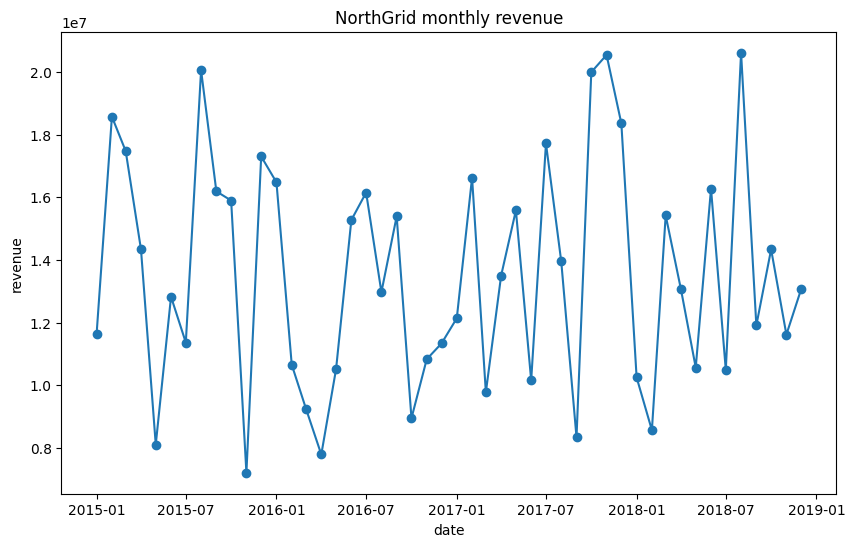

In [4]:
# Visualize revenue over time
plt.figure(figsize=(10,6))
plt.title('NorthGrid monthly revenue')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(NG_data['date'], NG_data['revenue'], marker='o')


In [5]:
# Find quantitative relationships
NG_data.loc[:, ['revenue','production','coolDD','heatDD']].corr()


,revenue,production,coolDD,heatDD
revenue,1.00,0.91,0.12,0.02
production,0.91,1.00,-0.24,0.24
coolDD,0.12,-0.24,1.00,-0.57
heatDD,0.02,0.24,-0.57,1.00


In [6]:
# Split into training and testing sets
dt4training = NG_data.loc[NG_data['type'] == 'dt4training']
dt4testing = NG_data.loc[NG_data['type'] == 'dt4testing']

display(dt4training)
display(dt4testing)


,date,revenue,production,coolDD,heatDD,type
0,2015-01-01,11650909,393487,47,455,dt4training
1,2015-02-01,18574693,721907,22,609,dt4training
2,2015-03-01,17476678,597236,61,203,dt4training
3,2015-04-01,14339607,521235,36,93,dt4training
4,2015-05-01,8105319,268930,178,33,dt4training
5,2015-06-01,12826066,268916,451,9,dt4training
6,2015-07-01,11362440,213107,493,35,dt4training
7,2015-08-01,20059530,673720,314,13,dt4training
8,2015-09-01,16190319,522635,180,30,dt4training
9,2015-10-01,15897373,583601,46,97,dt4training


,date,revenue,production,coolDD,heatDD,type
36,2018-01-01,10249325,353629,44,512,dt4testing
37,2018-02-01,8564821,235673,61,638,dt4testing
38,2018-03-01,15421518,570012,56,272,dt4testing
39,2018-04-01,13060522,430886,5,54,dt4testing
40,2018-05-01,10565125,249561,107,41,dt4testing
41,2018-06-01,16277871,462250,307,38,dt4testing
42,2018-07-01,10488037,199601,387,57,dt4testing
43,2018-08-01,20615932,698312,323,40,dt4testing
44,2018-09-01,11909857,327504,163,27,dt4testing
45,2018-10-01,14336215,557637,29,121,dt4testing


## Model 1: Production + CoolDD (Multivariate)

In [7]:
# Prepare dependent variable
y = dt4training.loc[:, 'revenue']

# Prepare independent variables - production and coolDD
x1 = dt4training.loc[:, ['production', 'coolDD']]
x1 = sm.add_constant(x1)

model1 = sm.OLS(y, x1).fit()
model1.params


,0
const,2389345.20
production,22.71
coolDD,8241.77


revenue = 2,389,345 + 22.71 * production + 8,241.77 * coolDD

In [8]:
# Forecast on testing set
x1_test = dt4testing.loc[:, ['production', 'coolDD']]
x1_test = sm.add_constant(x1_test)

model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x1_test)
model1_assessment['model1_abs_pct_error'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue'])
    / model1_assessment['revenue']
)
display(model1_assessment)


,date,revenue,production,coolDD,heatDD,type,model1_predicted_revenue,model1_abs_pct_error
36,2018-01-01,10249325,353629,44,512,dt4testing,10784385.75,0.05
37,2018-02-01,8564821,235673,61,638,dt4testing,8245218.80,0.04
38,2018-03-01,15421518,570012,56,272,dt4testing,15798255.42,0.02
39,2018-04-01,13060522,430886,5,54,dt4testing,12217788.17,0.06
40,2018-05-01,10565125,249561,107,41,dt4testing,8939795.25,0.15
41,2018-06-01,16277871,462250,307,38,dt4testing,15419211.86,0.05
42,2018-07-01,10488037,199601,387,57,dt4testing,10112689.72,0.04
43,2018-08-01,20615932,698312,323,40,dt4testing,20913041.52,0.01
44,2018-09-01,11909857,327504,163,27,dt4testing,11171748.00,0.06
45,2018-10-01,14336215,557637,29,121,dt4testing,15294639.25,0.07


In [9]:
model1_MAPE = model1_assessment['model1_abs_pct_error'].mean()
print(f'Model 1 MAPE: {model1_MAPE:.4f}')


Model 1 MAPE: 0.0554


## Model 2: Production + HeatDD (Multivariate)

In [10]:
# Prepare independent variables - production and heatDD
x2 = dt4training.loc[:, ['production', 'heatDD']]
x2 = sm.add_constant(x2)

model2 = sm.OLS(y, x2).fit()
model2.params


,0
const,4674502.85
production,22.12
heatDD,-4262.85


revenue = 4,674,503 + 22.12 * production + (-4,262.85) * heatDD

In [11]:
# Forecast on testing set
x2_test = dt4testing.loc[:, ['production', 'heatDD']]
x2_test = sm.add_constant(x2_test)

model1_assessment['model2_predicted_revenue'] = model2.predict(x2_test)
model1_assessment['model2_abs_pct_error'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model2_predicted_revenue'])
    / model1_assessment['revenue']
)
display(model1_assessment)


,date,revenue,production,coolDD,heatDD,type,model1_predicted_revenue,model1_abs_pct_error,model2_predicted_revenue,model2_abs_pct_error
36,2018-01-01,10249325,353629,44,512,dt4testing,10784385.75,0.05,10314092.45,0.01
37,2018-02-01,8564821,235673,61,638,dt4testing,8245218.80,0.04,7167822.16,0.16
38,2018-03-01,15421518,570012,56,272,dt4testing,15798255.42,0.02,16123503.22,0.05
39,2018-04-01,13060522,430886,5,54,dt4testing,12217788.17,0.06,13975378.54,0.07
40,2018-05-01,10565125,249561,107,41,dt4testing,8939795.25,0.15,10019940.78,0.05
41,2018-06-01,16277871,462250,307,38,dt4testing,15419211.86,0.05,14737346.41,0.09
42,2018-07-01,10488037,199601,387,57,dt4testing,10112689.72,0.04,8846634.96,0.16
43,2018-08-01,20615932,698312,323,40,dt4testing,20913041.52,0.01,19950441.57,0.03
44,2018-09-01,11909857,327504,163,27,dt4testing,11171748.00,0.06,11803696.51,0.01
45,2018-10-01,14336215,557637,29,121,dt4testing,15294639.25,0.07,16493461.95,0.15


In [12]:
model2_MAPE = model1_assessment['model2_abs_pct_error'].mean()
print(f'Model 2 MAPE: {model2_MAPE:.4f}')


Model 2 MAPE: 0.0703


## Model 3: Production + Summer Dummy Variable + Interaction Term

In [13]:
# Summer months: June, July, August
NG_data['summer_DV'] = np.where(NG_data['date'].dt.month.isin([6, 7, 8]), 1, 0)

# Interaction term: production * summer dummy
NG_data['summer_interaction'] = NG_data['production'] * NG_data['summer_DV']

display(NG_data)


,date,revenue,production,coolDD,heatDD,type,summer_DV,summer_interaction
0,2015-01-01,11650909,393487,47,455,dt4training,0,0
1,2015-02-01,18574693,721907,22,609,dt4training,0,0
2,2015-03-01,17476678,597236,61,203,dt4training,0,0
3,2015-04-01,14339607,521235,36,93,dt4training,0,0
4,2015-05-01,8105319,268930,178,33,dt4training,0,0
5,2015-06-01,12826066,268916,451,9,dt4training,1,268916
6,2015-07-01,11362440,213107,493,35,dt4training,1,213107
7,2015-08-01,20059530,673720,314,13,dt4training,1,673720
8,2015-09-01,16190319,522635,180,30,dt4training,0,0
9,2015-10-01,15897373,583601,46,97,dt4training,0,0


In [14]:
# Re-split with dummy variables included
dt4training = NG_data.loc[NG_data['type'] == 'dt4training']
dt4testing = NG_data.loc[NG_data['type'] == 'dt4testing']


In [15]:
# Train Model 3
x3 = dt4training.loc[:, ['production', 'summer_DV', 'summer_interaction']]
x3 = sm.add_constant(x3)

model3 = sm.OLS(dt4training['revenue'], x3).fit()
model3.params


,0
const,2839173.64
production,22.72
summer_DV,4449435.89
summer_interaction,-3.73


Non-summer: revenue = 2,839,174 + 22.72 * production

Summer: revenue = 7,288,610 + 18.99 * production


In [16]:
# Forecast on testing set
x3_test = dt4testing.loc[:, ['production', 'summer_DV', 'summer_interaction']]
x3_test = sm.add_constant(x3_test)

model3_assessment = dt4testing.copy()
model3_assessment['model3_predicted_revenue'] = model3.predict(x3_test)
model3_assessment['model3_abs_pct_error'] = abs(
    (model3_assessment['revenue'] - model3_assessment['model3_predicted_revenue'])
    / model3_assessment['revenue']
)
display(model3_assessment)


,date,revenue,production,coolDD,heatDD,type,summer_DV,summer_interaction,model3_predicted_revenue,model3_abs_pct_error
36,2018-01-01,10249325,353629,44,512,dt4testing,0,0,10872718.24,0.06
37,2018-02-01,8564821,235673,61,638,dt4testing,0,0,8193060.22,0.04
38,2018-03-01,15421518,570012,56,272,dt4testing,0,0,15788385.45,0.02
39,2018-04-01,13060522,430886,5,54,dt4testing,0,0,12627799.28,0.03
40,2018-05-01,10565125,249561,107,41,dt4testing,0,0,8508559.98,0.19
41,2018-06-01,16277871,462250,307,38,dt4testing,1,462250,16065061.15,0.01
42,2018-07-01,10488037,199601,387,57,dt4testing,1,199601,11078308.87,0.06
43,2018-08-01,20615932,698312,323,40,dt4testing,1,698312,20547022.70,0.00
44,2018-09-01,11909857,327504,163,27,dt4testing,0,0,10279225.19,0.14
45,2018-10-01,14336215,557637,29,121,dt4testing,0,0,15507257.17,0.08


In [17]:
model3_MAPE = model3_assessment['model3_abs_pct_error'].mean()
print(f'Model 3 MAPE: {model3_MAPE:.4f}')


Model 3 MAPE: 0.0624


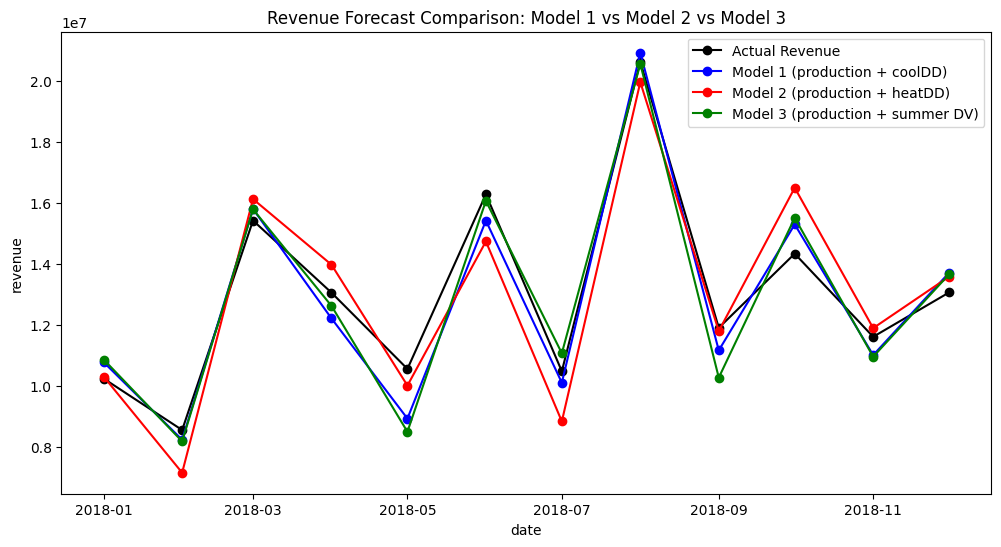

In [18]:
# Visualize actual vs predicted for all models
plt.figure(figsize=(12,6))
plt.title('Revenue Forecast Comparison: Model 1 vs Model 2 vs Model 3')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(model1_assessment['date'], model1_assessment['revenue'], marker='o', label='Actual Revenue', color='black')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'], marker='o', label='Model 1 (production + coolDD)', color='blue')
plt.plot(model1_assessment['date'], model1_assessment['model2_predicted_revenue'], marker='o', label='Model 2 (production + heatDD)', color='red')
plt.plot(model3_assessment['date'], model3_assessment['model3_predicted_revenue'], marker='o', label='Model 3 (production + summer DV)', color='green')
plt.legend()
